# Memory-efficient N-qubit GHZ distillation

This notebook implements the alternating two-copy protocol without constructing a dense $2N$-qubit unitary, a $4^N\times4^N$ joint density matrix, or measurement projectors. It stores only $N$-qubit density matrices of shape $2^N\times2^N$.

> **Scaling:** exact dense-state storage is $O(4^N)$. The optimized CXX round costs $O(4^N)$; the optimized CXH round costs $O(N4^N)$ using a Walsh–Hadamard XOR convolution. A general mixed $N$-qubit state still requires $4^N$ complex numbers, so sufficiently large $N$ ultimately requires symmetry or tensor-network compression.

The default accepted measurement sets are:

- **CXX rounds:** $\{0^N,1^N\}$. For $N=3$: `000`, `111`.
- **CXH rounds:** every even-parity outcome. For $N=3$: `000`, `011`, `101`, `110`.


## Measurement convention

For an accepted set $S$, the unnormalized branches are added,

$$\widetilde\rho_S=\sum_{m\in S}K_m(\rho_1\otimes\rho_2)K_m^\dagger,$$

and the conditional output is $\rho_S=\widetilde\rho_S/\operatorname{Tr}(\widetilde\rho_S)$. This is the correct state when the measurement result is recorded classically but no outcome-dependent quantum correction is applied before the next common operation. If the intended protocol applies different feed-forward corrections to different outcomes, apply those corrections to the individual branches before summing them.

Qubit ordering follows NumPy's Kronecker convention: qubit 0 is the most-significant bit. The two input registers are ordered as all system qubits followed by all ancilla-copy qubits.


In [15]:
from __future__ import annotations

from dataclasses import dataclass
from functools import reduce
from typing import Iterable, Sequence

import matplotlib.pyplot as plt
import numpy as np


In [35]:
# Set matplotlib parameters for better aesthetics
plt.rcParams.update({
    "font.family": "serif",
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

In [16]:
def _validate_N(N: int) -> int:
    if not isinstance(N, (int, np.integer)) or isinstance(N, bool) or N < 1:
        raise ValueError("N must be a positive integer")
    return int(N)


def outcome_index(outcome: int | str | Sequence[int], N: int) -> int:
    """Convert an integer, bit string, or bit sequence to a basis index."""
    N = _validate_N(N)
    dimension = 1 << N

    if isinstance(outcome, (int, np.integer)) and not isinstance(outcome, bool):
        index = int(outcome)
    elif isinstance(outcome, str):
        if len(outcome) != N or set(outcome) - {"0", "1"}:
            raise ValueError(f"Outcome must be a {N}-bit binary string")
        index = int(outcome, 2)
    else:
        bits = tuple(int(bit) for bit in outcome)
        if len(bits) != N or any(bit not in (0, 1) for bit in bits):
            raise ValueError(f"Outcome must contain exactly {N} binary values")
        index = int("".join(map(str, bits)), 2)

    if not 0 <= index < dimension:
        raise ValueError(f"Outcome index must lie in [0, {dimension})")
    return index


def normalize_outcomes(outcomes: Iterable[int | str | Sequence[int]], N: int) -> tuple[int, ...]:
    """Parse outcomes, remove duplicates, and preserve the supplied order."""
    parsed = tuple(dict.fromkeys(outcome_index(outcome, N) for outcome in outcomes))
    if not parsed:
        raise ValueError("At least one measurement outcome must be accepted")
    return parsed


def format_outcome(outcome: int, N: int) -> str:
    return format(outcome_index(outcome, N), f"0{N}b")


def cxx_default_outcomes(N: int) -> tuple[int, int]:
    N = _validate_N(N)
    return 0, (1 << N) - 1


def cxh_even_parity_outcomes(N: int) -> tuple[int, ...]:
    N = _validate_N(N)
    return tuple(index for index in range(1 << N) if index.bit_count() % 2 == 0)


def ghz_state(N: int) -> np.ndarray:
    N = _validate_N(N)
    state = np.zeros(1 << N, dtype=np.complex128)
    state[0] = state[-1] = 1 / np.sqrt(2)
    return state


def ghz_density_matrix(N: int) -> np.ndarray:
    state = ghz_state(N)
    return np.outer(state, state.conj())


def depolarized_ghz_state(N: int, noise_strength: float) -> np.ndarray:
    """(1-lambda)|GHZ><GHZ| + lambda I/2**N, for 0 <= lambda <= 1."""
    N = _validate_N(N)
    if not np.isfinite(noise_strength) or not 0 <= noise_strength <= 1:
        raise ValueError("noise_strength must lie in [0, 1]")
    dimension = 1 << N
    return (
        (1 - noise_strength) * ghz_density_matrix(N)
        + noise_strength * np.eye(dimension, dtype=np.complex128) / dimension
    )


In [17]:
def validate_density_matrix(
    rho: np.ndarray,
    N: int,
    *,
    check_psd: bool = True,
    atol: float = 1e-12,
) -> np.ndarray:
    """Validate shape, finiteness, Hermiticity, trace, and optionally positivity."""
    N = _validate_N(N)
    dimension = 1 << N
    matrix = np.asarray(rho, dtype=np.complex128)

    if matrix.shape != (dimension, dimension):
        raise ValueError(
            f"Expected a {(dimension, dimension)} density matrix, got {matrix.shape}"
        )
    if not np.all(np.isfinite(matrix)):
        raise ValueError("Density matrix contains NaN or infinite values")

    scale = max(1.0, np.linalg.norm(matrix, ord="fro"))
    hermitian_error = np.linalg.norm(matrix - matrix.conj().T, ord="fro")
    if hermitian_error > atol * scale:
        raise ValueError(f"Density matrix is not Hermitian; error={hermitian_error:.3e}")

    trace = np.trace(matrix)
    if abs(trace.imag) > atol * scale or abs(trace.real - 1.0) > atol * scale:
        raise ValueError(f"Density matrix must have trace one; trace={trace}")

    if check_psd:
        minimum_eigenvalue = np.linalg.eigvalsh((matrix + matrix.conj().T) / 2).min()
        if minimum_eigenvalue < -atol * scale:
            raise ValueError(
                f"Density matrix is not positive semidefinite; min eigenvalue={minimum_eigenvalue:.3e}"
            )

    return matrix


def _normalize_postselection(
    unnormalized: np.ndarray, *, atol: float = 1e-13
) -> tuple[np.ndarray, float]:
    matrix = np.asarray(unnormalized, dtype=np.complex128)
    scale = max(1.0, np.linalg.norm(matrix, ord="fro"))
    probability = np.trace(matrix)

    if abs(probability.imag) > atol * scale:
        raise FloatingPointError(
            f"Postselection probability is not real: {probability}"
        )
    probability = float(probability.real)
    if probability <= atol * scale:
        raise FloatingPointError(
            f"Accepted outcomes have zero/negligible probability: {probability:.3e}"
        )
    if probability > 1 + atol * scale:
        raise FloatingPointError(f"Postselection probability exceeds one: {probability}")

    hermitian_error = np.linalg.norm(matrix - matrix.conj().T, ord="fro")
    if hermitian_error > 100 * atol * scale:
        raise FloatingPointError(
            f"Postselected state lost Hermiticity; error={hermitian_error:.3e}"
        )

    # Remove only round-off-level anti-Hermitian noise.
    matrix = (matrix + matrix.conj().T) / 2
    return matrix / probability, probability


def pure_state_fidelity(rho: np.ndarray, target: np.ndarray, *, atol: float = 1e-12) -> float:
    target = np.asarray(target, dtype=np.complex128)
    norm = np.vdot(target, target).real
    if not np.isclose(norm, 1.0, rtol=0.0, atol=atol):
        raise ValueError(f"Target state must be normalized; norm squared={norm}")
    value = np.vdot(target, np.asarray(rho) @ target)
    if abs(value.imag) > atol:
        raise FloatingPointError(f"Fidelity has a material imaginary part: {value}")
    return float(value.real)


## Exact reduced-state kernels

For CXX and a single outcome $m$, the branch is an elementwise product with an XOR-permuted ancilla density matrix. For CXH, each branch is a two-dimensional XOR convolution. The convolution is evaluated with an unnormalized fast Walsh–Hadamard transform (FWHT).

For the full even-parity CXH acceptance set, the character sum is evaluated analytically. Only ancilla elements satisfying $b=a$ or $b=a\oplus(2^N-1)$ survive, each with weight $1/2$. Therefore all $2^{N-1}$ accepted CXH outcomes require only one convolution.


In [18]:
def fwht(values: np.ndarray) -> np.ndarray:
    """Unnormalized one-dimensional fast Walsh-Hadamard transform."""
    result = np.array(values, dtype=np.complex128, copy=True)
    size = result.size
    if size == 0 or size & (size - 1):
        raise ValueError("FWHT input size must be a power of two")

    block = 1
    while block < size:
        view = result.reshape(-1, 2 * block)
        left = view[:, :block].copy()
        right = view[:, block:].copy()
        view[:, :block] = left + right
        view[:, block:] = left - right
        block *= 2
    return result


def xor_convolution_2d(left: np.ndarray, right: np.ndarray) -> np.ndarray:
    """XOR convolution over the row and column bit strings."""
    left = np.asarray(left, dtype=np.complex128)
    right = np.asarray(right, dtype=np.complex128)
    if left.shape != right.shape or left.ndim != 2 or left.shape[0] != left.shape[1]:
        raise ValueError("Inputs must be equally sized square matrices")
    size = left.size
    transformed = fwht(left.ravel()) * fwht(right.ravel())
    return (fwht(transformed) / size).reshape(left.shape)


def _cxx_outcome_unnormalized(
    rho_system: np.ndarray, rho_ancilla: np.ndarray, N: int, outcome: int
) -> np.ndarray:
    dimension = 1 << N
    all_ones = dimension - 1
    permutation = np.arange(dimension, dtype=np.int64) ^ outcome ^ all_ones
    return rho_system * rho_ancilla[np.ix_(permutation, permutation)]


def _cxh_outcome_unnormalized(
    rho_system: np.ndarray, rho_ancilla: np.ndarray, N: int, outcome: int
) -> np.ndarray:
    dimension = 1 << N
    phase = np.fromiter(
        (
            -1.0 if ((basis_index & outcome).bit_count() & 1) else 1.0
            for basis_index in range(dimension)
        ),
        dtype=float,
        count=dimension,
    ) / np.sqrt(dimension)
    weighted_ancilla = phase[:, None] * rho_ancilla * phase.conj()[None, :]
    return xor_convolution_2d(rho_system, weighted_ancilla)


In [19]:
@dataclass(frozen=True)
class AcceptedRound:
    gate: str
    state: np.ndarray
    round_acceptance_probability: float
    accepted_outcomes: tuple[int, ...]
    branch_probabilities: dict[int, float] | None = None

    def outcome_labels(self, N: int) -> tuple[str, ...]:
        return tuple(format_outcome(outcome, N) for outcome in self.accepted_outcomes)

    @property
    def success_probability(self) -> float:
        """Backward-compatible alias for the local, one-operation probability."""
        return self.round_acceptance_probability


def cxx_accepted_round(
    rho_system: np.ndarray,
    rho_ancilla: np.ndarray,
    N: int,
    accepted_outcomes: Iterable[int | str | Sequence[int]] | None = None,
) -> AcceptedRound:
    """CXX round accepting 0**N and 1**N by default."""
    N = _validate_N(N)
    rho_system = validate_density_matrix(rho_system, N, check_psd=False)
    rho_ancilla = validate_density_matrix(rho_ancilla, N, check_psd=False)
    outcomes = (
        cxx_default_outcomes(N)
        if accepted_outcomes is None
        else normalize_outcomes(accepted_outcomes, N)
    )

    unnormalized = np.zeros_like(rho_system, dtype=np.complex128)
    branch_probabilities: dict[int, float] = {}
    for outcome in outcomes:
        branch = _cxx_outcome_unnormalized(rho_system, rho_ancilla, N, outcome)
        branch_probability = np.trace(branch)
        if abs(branch_probability.imag) > 1e-12:
            raise FloatingPointError("A CXX branch probability is not real")
        branch_probabilities[outcome] = float(branch_probability.real)
        unnormalized += branch

    state, probability = _normalize_postselection(unnormalized)
    return AcceptedRound(
        gate="CXX",
        state=state,
        round_acceptance_probability=probability,
        accepted_outcomes=outcomes,
        branch_probabilities=branch_probabilities,
    )


def cxh_accepted_round(
    rho_system: np.ndarray,
    rho_ancilla: np.ndarray,
    N: int,
    accepted_outcomes: Iterable[int | str | Sequence[int]] | None = None,
    *,
    diagnostics: bool = False,
) -> AcceptedRound:
    """
    CXH round accepting every even-parity outcome by default.

    The default set uses an O(N*4**N) closed form. A custom set uses
    O((N + number_of_outcomes)*4**N) work but the same O(4**N) memory.
    diagnostics=True computes every branch separately and is intended only
    for small-N verification.
    """
    N = _validate_N(N)
    rho_system = validate_density_matrix(rho_system, N, check_psd=False)
    rho_ancilla = validate_density_matrix(rho_ancilla, N, check_psd=False)
    even_outcomes = cxh_even_parity_outcomes(N)
    outcomes = (
        even_outcomes
        if accepted_outcomes is None
        else normalize_outcomes(accepted_outcomes, N)
    )

    dimension = 1 << N
    basis = np.arange(dimension, dtype=np.int64)

    if len(outcomes) == len(even_outcomes) and frozenset(outcomes) == frozenset(even_outcomes):
        # Character sum over the even-parity subgroup. Only b=a and
        # b=a XOR (11...1) survive, each with coefficient 1/2.
        weighted_ancilla = np.zeros_like(rho_ancilla, dtype=np.complex128)
        complement = basis ^ (dimension - 1)
        weighted_ancilla[basis, basis] = 0.5 * rho_ancilla[basis, basis]
        weighted_ancilla[basis, complement] = 0.5 * rho_ancilla[basis, complement]
    else:
        weighted_ancilla = np.zeros_like(rho_ancilla, dtype=np.complex128)
        for outcome in outcomes:
            phase = np.fromiter(
                (
                    -1.0 if ((basis_index & outcome).bit_count() & 1) else 1.0
                    for basis_index in range(dimension)
                ),
                dtype=float,
                count=dimension,
            ) / np.sqrt(dimension)
            weighted_ancilla += phase[:, None] * rho_ancilla * phase.conj()[None, :]

    unnormalized = xor_convolution_2d(rho_system, weighted_ancilla)
    state, probability = _normalize_postselection(unnormalized)

    branch_probabilities = None
    if diagnostics:
        branch_probabilities = {}
        for outcome in outcomes:
            branch = _cxh_outcome_unnormalized(rho_system, rho_ancilla, N, outcome)
            branch_probability = np.trace(branch)
            if abs(branch_probability.imag) > 1e-12:
                raise FloatingPointError("A CXH branch probability is not real")
            branch_probabilities[outcome] = float(branch_probability.real)
        if not np.isclose(
            sum(branch_probabilities.values()), probability, rtol=1e-11, atol=1e-13
        ):
            raise AssertionError("CXH branch probabilities do not sum to the total")

    return AcceptedRound(
        gate="CXH",
        state=state,
        round_acceptance_probability=probability,
        accepted_outcomes=outcomes,
        branch_probabilities=branch_probabilities,
    )


In [20]:
@dataclass(frozen=True)
class AlternatingTrajectory:
    initial_state: np.ndarray
    rounds: tuple[AcceptedRound, ...]

    @property
    def states(self) -> tuple[np.ndarray, ...]:
        return (self.initial_state,) + tuple(result.state for result in self.rounds)

    @property
    def round_acceptance_probabilities(self) -> np.ndarray:
        return np.asarray(
            [result.round_acceptance_probability for result in self.rounds], dtype=float
        )

    @property
    def round_success_probabilities(self) -> np.ndarray:
        """Backward-compatible alias; these are local acceptance probabilities."""
        return self.round_acceptance_probabilities

    def fidelity_history(self, target: np.ndarray) -> np.ndarray:
        return np.asarray(
            [pure_state_fidelity(state, target) for state in self.states], dtype=float
        )

    def binary_tree_log_success_probabilities(self) -> np.ndarray:
        """
        Log probability of preparing one level-r output from 2**r raw inputs.

        If p_r is the conditional acceptance probability of the level-r
        operation, then Y_0=1 and Y_r=p_r*Y_(r-1)**2. Hence
        Y_2=p_1**2*p_2 and Y_3=p_1**4*p_2**2*p_3.
        """
        values = [0.0]
        log_success_probability = 0.0
        for result in self.rounds:
            log_success_probability = (
                np.log(result.round_acceptance_probability)
                + 2 * log_success_probability
            )
            values.append(log_success_probability)
        return np.asarray(values, dtype=float)

    def binary_tree_success_probabilities(self) -> np.ndarray:
        """Total preparation probabilities Y_r; may underflow for deep trees."""
        return np.exp(self.binary_tree_log_success_probabilities())

    def binary_tree_log_yields(self) -> np.ndarray:
        """Backward-compatible alias for binary_tree_log_success_probabilities()."""
        return self.binary_tree_log_success_probabilities()


def alternating_protocol(
    rho0: np.ndarray,
    N: int,
    number_of_rounds: int,
    *,
    cxx_outcomes: Iterable[int | str | Sequence[int]] | None = None,
    cxh_outcomes: Iterable[int | str | Sequence[int]] | None = None,
    diagnostics: bool = False,
) -> AlternatingTrajectory:
    """
    Alternate CXX, CXH, CXX, CXH, ... using two identical copies each round.

    Defaults:
      CXX accepts 0**N and 1**N.
      CXH accepts all even-parity N-bit outcomes.
    """
    N = _validate_N(N)
    if (
        not isinstance(number_of_rounds, (int, np.integer))
        or isinstance(number_of_rounds, bool)
        or number_of_rounds < 0
    ):
        raise ValueError("number_of_rounds must be a nonnegative integer")

    initial_state = validate_density_matrix(rho0, N, check_psd=True)
    state = initial_state.copy()
    results: list[AcceptedRound] = []

    for iteration in range(int(number_of_rounds)):
        if iteration % 2 == 0:
            result = cxx_accepted_round(
                state, state, N, accepted_outcomes=cxx_outcomes
            )
        else:
            result = cxh_accepted_round(
                state,
                state,
                N,
                accepted_outcomes=cxh_outcomes,
                diagnostics=diagnostics,
            )
        state = result.state
        results.append(result)

    return AlternatingTrajectory(initial_state=initial_state, rounds=tuple(results))


## Three-qubit example

The following uses precisely the requested acceptance rules. It reports both the local acceptance probability $p_r$ of one operation and the binary-tree preparation probability $Y_r=p_rY_{r-1}^2$. Round $r$ consumes $2^r$ raw input states. `diagnostics=True` computes the individual CXH branch probabilities; leave it `False` for larger $N$ because the optimized total probability does not require enumerating every branch.


In [21]:
N = 3
noise_strength = 0.05
number_of_rounds = 6

target = ghz_state(N)
rho_initial = depolarized_ghz_state(N, noise_strength)
trajectory = alternating_protocol(
    rho_initial, N, number_of_rounds, diagnostics=True
)
fidelities = trajectory.fidelity_history(target)
round_acceptance_probabilities = trajectory.round_acceptance_probabilities
tree_success_probabilities = trajectory.binary_tree_success_probabilities()

print(f"Initial fidelity: {fidelities[0]:.12f}")
for iteration, result in enumerate(trajectory.rounds, start=1):
    labels = ", ".join(result.outcome_labels(N))
    branch_text = ""
    if result.branch_probabilities is not None:
        branch_text = "; branches: " + ", ".join(
            f"{format_outcome(outcome, N)}={probability:.6g}"
            for outcome, probability in result.branch_probabilities.items()
        )
    print(
        f"Round {iteration}: {result.gate}; accept [{labels}]; "
        f"local p_{iteration}={result.round_acceptance_probability:.12g}; "
        f"tree P_{iteration}={tree_success_probabilities[iteration]:.12g}; "
        f"raw copies={1 << iteration}; F={fidelities[iteration]:.12f}"
        f"{branch_text}"
    )


Initial fidelity: 0.956250000000
Round 1: CXX; accept [000, 111]; local p_1=0.926875; tree P_1=0.926875; raw copies=2; F=0.986598111935; branches: 000=0.463437, 111=0.463437
Round 2: CXH; accept [000, 011, 101, 110]; local p_2=0.974047749068; tree P_2=0.836801757812; raw copies=4; F=0.999310204987; branches: 000=0.243512, 011=0.243512, 101=0.243512, 110=0.243512
Round 3: CXX; accept [000, 111]; local p_3=0.998962296907; tree P_3=0.699510543589; raw copies=8; F=0.999658263422; branches: 000=0.499481, 111=0.499481
Round 4: CXH; accept [000, 011, 101, 110]; local p_4=0.999316935467; tree P_4=0.488980766869; raw copies=16; F=0.999999707962; branches: 000=0.249829, 011=0.249829, 101=0.249829, 110=0.249829
Round 5: CXX; accept [000, 111]; local p_5=0.999999649529; tree P_5=0.23910210657; raw copies=32; F=0.999999766395; branches: 000=0.5, 111=0.5
Round 6: CXH; accept [000, 011, 101, 110]; local p_6=0.999999532791; tree P_6=0.0571697906559; raw copies=64; F=1.000000000000; branches: 000=0.25,

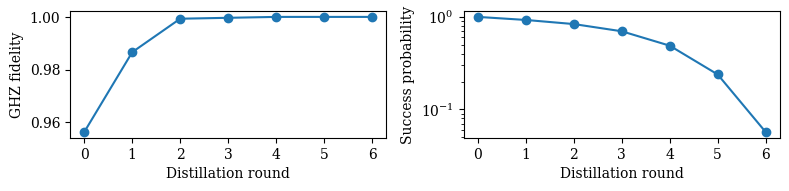

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(8, 2.))
round_numbers = np.arange(number_of_rounds + 1)

axes[0].plot(round_numbers, fidelities, "o-")
axes[0].set(xlabel="Distillation round", ylabel="GHZ fidelity")
#axes[0].grid(alpha=0.3)

axes[1].semilogy(round_numbers, tree_success_probabilities, "o-")
axes[1].set(
    xlabel="Distillation round",
    ylabel="Success probability",
)
#axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()


## Comparison across system sizes: $N=2,3,4,5,6,7$

Each curve below uses the same depolarizing-noise strength, number of rounds, alternating gate order, and default acceptance rules. CXX accepts $\{0^N,1^N\}$, while CXH accepts all $2^{N-1}$ even-parity outcomes. The plotted total probability is the binary-tree preparation probability $Y_r=p_rY_{r-1}^2$, not merely the local acceptance probability $p_r$. Even for $N=7$, the implementation stores only $128\times128$ density matrices.


In [27]:
comparison_N_values = tuple(range(2, 8))
comparison_noise_strength = 0.05
comparison_number_of_rounds = 6

comparison_results = {}
for N_compare in comparison_N_values:
    target_compare = ghz_state(N_compare)
    rho_compare = depolarized_ghz_state(N_compare, comparison_noise_strength)
    trajectory_compare = alternating_protocol(
        rho_compare, N_compare, comparison_number_of_rounds, diagnostics=False
    )
    comparison_results[N_compare] = {
        "trajectory": trajectory_compare,
        "fidelities": trajectory_compare.fidelity_history(target_compare),
        "local_probabilities": trajectory_compare.round_acceptance_probabilities,
        "tree_probabilities": trajectory_compare.binary_tree_success_probabilities(),
    }

print(
    f"{'N':>2} {'CXH outcomes':>12} {'F_initial':>14} "
    f"{'F_final':>14} {'P_tree_final':>16}"
)
for N_compare in comparison_N_values:
    result = comparison_results[N_compare]
    print(
        f"{N_compare:2d} {1 << (N_compare - 1):12d} "
        f"{result['fidelities'][0]:14.10f} "
        f"{result['fidelities'][-1]:14.10f} "
        f"{result['tree_probabilities'][-1]:16.10g}"
    )


 N CXH outcomes      F_initial        F_final     P_tree_final
 2            2   0.9625000000   1.0000000000    0.08709503368
 3            4   0.9562500000   1.0000000000    0.05716979066
 4            8   0.9531250000   1.0000000000    0.04631701135
 5           16   0.9515625000   1.0000000000    0.04168942146
 6           32   0.9507812500   1.0000000000    0.03955198942
 7           64   0.9503906250   1.0000000000     0.0385247243


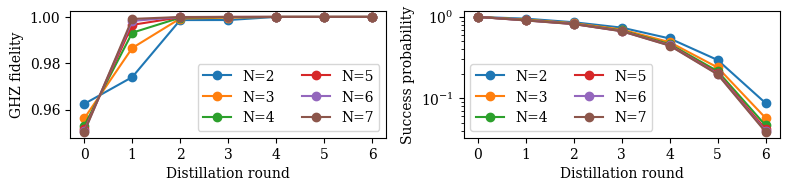

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(8, 2))
comparison_round_numbers = np.arange(comparison_number_of_rounds + 1)

for N_compare in comparison_N_values:
    result = comparison_results[N_compare]
    axes[0].plot(
        comparison_round_numbers, result['fidelities'], "o-", label=f"N={N_compare}"
    )
    axes[1].semilogy(
        comparison_round_numbers,
        result['tree_probabilities'],
        "o-",
        label=f"N={N_compare}",
    )

axes[0].set(xlabel="Distillation round", ylabel="GHZ fidelity")
axes[1].set(
    xlabel="Distillation round",
    ylabel="Success probability",
)
for axis in axes:
    axis.set_xticks(comparison_round_numbers)
    #axis.grid(alpha=0.25)
    axis.legend(ncol=2)

fig.tight_layout()
plt.show()


## Independent dense validation for $N=3$

This cell constructs the full six-qubit operators only as a small regression oracle. It is not used by the production implementation. The optimized accepted states and probabilities are compared against explicit dense evolution for two distinct random physical inputs.


In [24]:
def _dense_reference_accepted(
    rho_system: np.ndarray,
    rho_ancilla: np.ndarray,
    N: int,
    gate: str,
    outcomes: Iterable[int],
) -> np.ndarray:
    """Small-N dense oracle; do not use for production calculations."""
    dimension = 1 << N
    joint_dimension = dimension * dimension
    columns = np.arange(joint_dimension, dtype=np.int64)
    system = columns // dimension
    ancilla = columns % dimension

    if gate == "CXX":
        rows = system * dimension + (ancilla ^ system ^ (dimension - 1))
        unitary = np.zeros((joint_dimension, joint_dimension), dtype=np.complex128)
        unitary[rows, columns] = 1
    elif gate == "CXH":
        rows = (system ^ ancilla) * dimension + ancilla
        reverse_cnot = np.zeros(
            (joint_dimension, joint_dimension), dtype=np.complex128
        )
        reverse_cnot[rows, columns] = 1
        hadamard = np.array([[1, 1], [1, -1]], dtype=np.complex128) / np.sqrt(2)
        hadamard_all = reduce(np.kron, [hadamard] * N)
        unitary = np.kron(np.eye(dimension), hadamard_all) @ reverse_cnot
    else:
        raise ValueError("gate must be 'CXX' or 'CXH'")

    joint_state = np.kron(rho_system, rho_ancilla)
    result = np.zeros((dimension, dimension), dtype=np.complex128)
    for outcome in outcomes:
        selected_rows = np.arange(dimension) * dimension + outcome
        kraus = unitary[selected_rows, :]
        result += kraus @ joint_state @ kraus.conj().T
    return result


def _random_density_matrix(dimension: int, rng: np.random.Generator) -> np.ndarray:
    factor = (
        rng.normal(size=(dimension, dimension))
        + 1j * rng.normal(size=(dimension, dimension))
    )
    matrix = factor @ factor.conj().T
    return matrix / np.trace(matrix).real


rng = np.random.default_rng(20260730)
N_test = 3
d_test = 1 << N_test
rho_a = _random_density_matrix(d_test, rng)
rho_b = _random_density_matrix(d_test, rng)

fast_cxx = cxx_accepted_round(rho_a, rho_b, N_test)
dense_cxx = _dense_reference_accepted(
    rho_a, rho_b, N_test, "CXX", cxx_default_outcomes(N_test)
)
dense_cxx_state, dense_cxx_probability = _normalize_postselection(dense_cxx)

fast_cxh = cxh_accepted_round(rho_a, rho_b, N_test)
dense_cxh = _dense_reference_accepted(
    rho_a, rho_b, N_test, "CXH", cxh_even_parity_outcomes(N_test)
)
dense_cxh_state, dense_cxh_probability = _normalize_postselection(dense_cxh)

cxx_state_error = np.max(np.abs(fast_cxx.state - dense_cxx_state))
cxh_state_error = np.max(np.abs(fast_cxh.state - dense_cxh_state))

assert fast_cxx.outcome_labels(N_test) == ("000", "111")
assert frozenset(fast_cxh.outcome_labels(N_test)) == frozenset(
    ("000", "011", "101", "110")
)
assert np.isclose(fast_cxx.round_acceptance_probability, dense_cxx_probability)
assert np.isclose(fast_cxh.round_acceptance_probability, dense_cxh_probability)
assert cxx_state_error < 1e-12
assert cxh_state_error < 1e-12

# Binary-tree resource accounting: level r needs two successful level-(r-1) states.
local_probabilities = trajectory.round_acceptance_probabilities
tree_probabilities = trajectory.binary_tree_success_probabilities()
assert np.isclose(tree_probabilities[0], 1.0)
assert np.isclose(tree_probabilities[1], local_probabilities[0])
assert np.isclose(
    tree_probabilities[2], local_probabilities[0] ** 2 * local_probabilities[1]
)
assert np.isclose(
    tree_probabilities[3],
    local_probabilities[0] ** 4
    * local_probabilities[1] ** 2
    * local_probabilities[2],
)

print(f"CXX dense-reference max error: {cxx_state_error:.3e}")
print(f"CXH dense-reference max error: {cxh_state_error:.3e}")
print("All acceptance-set and dense-reference tests passed.")


CXX dense-reference max error: 0.000e+00
CXH dense-reference max error: 2.776e-17
All acceptance-set and dense-reference tests passed.


## Usage notes

- `alternating_protocol` uses two identical copies of the current conditional state at every level, matching the original recursive alternating scheme.
- `round_acceptance_probability` is the local conditional probability $p_r$ that one level-$r$ operation accepts, assuming its two level-$(r-1)$ inputs are already available. It is the sum of all accepted measurement-branch probabilities in that operation.
- `binary_tree_success_probabilities()` returns the total preparation probabilities $Y_r$ from $2^r$ raw inputs: $Y_0=1$ and $Y_r=p_rY_{r-1}^2$. Therefore $Y_1=p_1$, $Y_2=p_1^2p_2$, and $Y_3=p_1^4p_2^2p_3$. Although rounds 1 and 3 both use CXX, generally $p_3\ne p_1$ because the input state has changed.
- `binary_tree_log_success_probabilities()` evaluates the same recurrence in log space to avoid silent numerical underflow for deep trees.
- Custom acceptance sets may be supplied as integers, bit strings such as `"011"`, or bit sequences. The even-parity CXH default has a special closed form and is faster than a general custom set.
- Keep `diagnostics=False` for large $N$; individual CXH branch probabilities are deliberately optional because enumerating them removes the benefit of the even-parity character sum.
- Exact full density matrices eventually become limiting: complex128 storage is $16\,4^N$ bytes per state (about 16 MiB at $N=10$, 256 MiB at $N=12$, and 4 GiB at $N=14$).
